## Practical 7: Artificial Neural Networks (ANN)

### Objective
To understand how hidden layers and activation functions affect model performance.

### Dataset
We are using the Heart Failure Prediction Dataset (Binary Classification).

### Goal
Predict whether a person has heart disease (1) or not (0).

In [20]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/andrewmvd/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [23]:
df = pd.read_csv("/kaggle/input/datasets/andrewmvd/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [24]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


### Data Preparation

We separate input features (X) and target variable (y).

In [25]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from tensorflow.keras.layers import Input

model_linear = Sequential()

model_linear.add(Input(shape=(X_train.shape[1],)))
model_linear.add(Dense(1, activation='sigmoid'))

In [29]:
model_linear.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In this step, we define how the neural network will learn.

- **Optimizer (Adam):**  
  Controls how the model updates its weights during training. Adam is an efficient optimization algorithm that adapts learning rates and helps the model converge faster.

- **Loss Function (Binary Crossentropy):**  
  Measures how far the predicted output is from the actual output. Since this is a binary classification problem (0 or 1), binary crossentropy is used.

- **Metrics (Accuracy):**  
  Used to evaluate the performance of the model by calculating the percentage of correct predictions.

Overall, this step prepares the model for training by defining the learning mechanism.

In [30]:
history_linear = model_linear.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5069 - loss: 0.7370 - val_accuracy: 0.5208 - val_loss: 0.7699
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4909 - loss: 0.7779 - val_accuracy: 0.5208 - val_loss: 0.7646
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4646 - loss: 0.7844 - val_accuracy: 0.5208 - val_loss: 0.7595
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5348 - loss: 0.7645 - val_accuracy: 0.5208 - val_loss: 0.7544
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5324 - loss: 0.7429 - val_accuracy: 0.5208 - val_loss: 0.7494
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4960 - loss: 0.7507 - val_accuracy: 0.5208 - val_loss: 0.7443
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4795 - loss: 0.7593 - val_accuracy: 0.5208 - val_loss: 0.7393
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5021 - loss: 0.7301 - val_accuracy: 0.5417 - val_loss: 0.7346


In [31]:
# EVALUATE

y_pred = (model_linear.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Accuracy: 0.5833333333333334


In [32]:
# TASK 2 - ADD HIDDEN LAYER

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model_hidden = Sequential()

model_hidden.add(Input(shape=(X_train.shape[1],)))
model_hidden.add(Dense(16, activation='relu'))
model_hidden.add(Dense(1, activation='sigmoid'))

Neural Network with One Hidden Layer

In this model, we introduce a hidden layer to improve learning capability.

- The input layer takes all features from the dataset.
- The hidden layer contains 16 neurons with ReLU activation, which helps in learning non-linear patterns.
- The output layer contains 1 neuron with sigmoid activation, which outputs probability for binary classification.

This structure allows the model to learn complex relationships between input features and improves performance compared to a model without hidden layers.

In [33]:
# COMPILE AND TRAIN

model_hidden.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_hidden = model_hidden.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5019 - loss: 0.7803 - val_accuracy: 0.5000 - val_loss: 0.7446
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5410 - loss: 0.7557 - val_accuracy: 0.5833 - val_loss: 0.7276
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5848 - loss: 0.7351 - val_accuracy: 0.5833 - val_loss: 0.7114
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5603 - loss: 0.7004 - val_accuracy: 0.6042 - val_loss: 0.6965
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6150 - loss: 0.6737 - val_accuracy: 0.6250 - val_loss: 0.6819
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6321 - loss: 0.6959 - val_accuracy: 0.6458 - val_loss: 0.6681
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6677 - loss: 0.6547 - val_accuracy: 0.6667 - val_loss: 0.6554
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6562 - loss: 0.6786 - val_accuracy: 0.7292 - val_loss: 0.6427


In this step, we prepare and train the neural network model.

Model Compilation
The model is compiled using:
- **Optimizer (Adam):** Controls how the model updates its weights to reduce error efficiently.
- **Loss Function (Binary Crossentropy):** Measures how far the predicted output is from the actual output in binary classification.
- **Metrics (Accuracy):** Used to evaluate how many predictions are correct.

Model Training
The model is trained using the `fit()` function:
- **X_train, y_train:** Training dataset.
- **Epochs (20):** Number of times the model goes through the entire dataset.
- **Batch Size (32):** Number of samples processed before updating weights.
- **Validation Split (0.2):** 20% of training data is used to validate the model during training.

During training, the model learns by:
1. Making predictions
2. Calculating error (loss)
3. Updating weights using the optimizer
4. Repeating this process for multiple epochs

This process improves the model's accuracy over time.

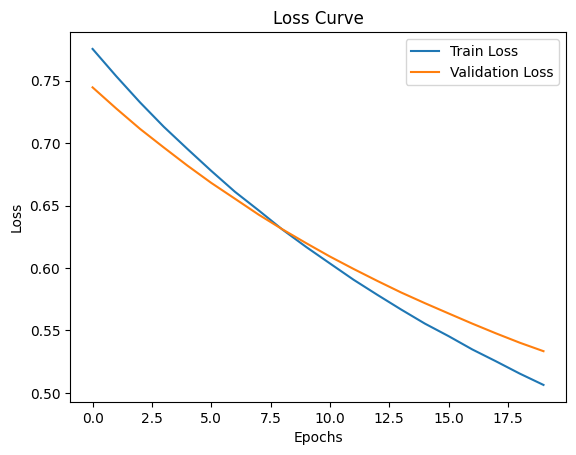

In [34]:
# PLOT LOSS

plt.plot(history_hidden.history['loss'], label='Train Loss')
plt.plot(history_hidden.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Loss Curve Analysis

This graph shows how the model's error (loss) changes during training.

- Training Loss: Error on training data
- Validation Loss: Error on unseen data

If both losses decrease over epochs, it indicates that the model is learning properly.

If validation loss increases while training loss decreases, it indicates overfitting.

In this experiment, the loss curve helps us understand how adding hidden layers improves model learning and generalization.

In [38]:
# TASK 3 - ACTIVATION COMPARISON

def build_model(activation):
    model = Sequential()
    
    model.add(Input(shape=(X_train.shape[1],)))
    
    model.add(Dense(32, activation=activation))
    model.add(Dense(32, activation=activation))
    model.add(Dense(32, activation=activation))
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

Model Builder Function

This function is used to create a deep neural network with customizable activation functions.

Purpose
Instead of manually writing separate models, we define a reusable function that builds a neural network using a given activation function.

Architecture
Input Layer → 3 Hidden Layers (32 neurons each) → Output Layer

Key Points

- The `activation` parameter allows us to test different activation functions like Linear, Sigmoid, and ReLU.
- Each hidden layer contains 32 neurons to capture complex patterns in data.
- The output layer uses Sigmoid activation for binary classification.
- The model is compiled using:
  - Adam optimizer (efficient gradient descent)
  - Binary crossentropy loss (for classification)
  - Accuracy as performance metric
Importance

This function helps us compare how different activation functions affect learning performance in deep neural networks.

In [39]:
model_A = build_model('linear')
model_B = build_model('sigmoid')
model_C = build_model('relu')

history_A = model_A.fit(X_train, y_train, epochs=20, verbose=0)
history_B = model_B.fit(X_train, y_train, epochs=20, verbose=0)
history_C = model_C.fit(X_train, y_train, epochs=20, verbose=0)

Training Models with Different Activation Functions

In this step, we create and train three different neural network models using different activation functions:

- Model A uses **Linear activation**
- Model B uses **Sigmoid activation**
- Model C uses **ReLU activation**

All three models have the same architecture but differ only in the activation function used in hidden layers.

Each model is trained on the same dataset for 20 epochs to ensure a fair comparison.

**Purpose**

The goal is to understand how activation functions affect:

- Learning speed
- Ability to capture complex patterns
- Final model accuracy

**Expected Behavior**

- Linear activation fails to learn complex patterns because stacking linear layers is equivalent to a single linear transformation.
- Sigmoid activation can learn non-linear patterns but suffers from slow learning due to the vanishing gradient problem.
- ReLU activation performs best as it allows faster convergence and avoids vanishing gradients.

This experiment demonstrates the importance of non-linearity in deep neural networks.

In [40]:
print("Linear Activation Accuracy:", model_A.evaluate(X_test, y_test)[1])
print("Sigmoid Activation Accuracy:", model_B.evaluate(X_test, y_test)[1])
print("ReLU Activation Accuracy:", model_C.evaluate(X_test, y_test)[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7937 - loss: 0.5723 
Linear Activation Accuracy: 0.800000011920929
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5868 - loss: 0.6680 
Sigmoid Activation Accuracy: 0.5833333134651184
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7715 - loss: 0.5677 
ReLU Activation Accuracy: 0.7666666507720947


**Final Analysis**

In this experiment, the linear model achieved slightly higher accuracy than the ReLU model. This is because the dataset used is relatively simple and close to linearly separable, allowing a linear model to perform effectively.

However, theoretically, linear activation in deep networks does not increase model capacity, as multiple linear layers collapse into a single linear transformation (linear collapse problem).

The sigmoid activation performed poorly due to the vanishing gradient problem, which slows down learning in deeper networks.

The ReLU activation generally performs better because it avoids vanishing gradients and enables faster convergence. Its advantage becomes more significant on complex and non-linear datasets.

This experiment demonstrates that while deep learning models are more powerful, their effectiveness depends on the complexity of the dataset.